# 🏥 Hospital Length-of-Stay Prediction
**CSE271 — Data Science Methodology | Spring 2026**  
**Egypt University of Informatics**

---
### Project Goal
Predict how long a patient will stay in hospital using clinical data.
- **Regression** → predict exact days (continuous)
- **Classification** → predict risk class: Short / Medium / Long stay

### Dataset
Microsoft Hospital LOS Dataset — [Kaggle Link](https://www.kaggle.com/datasets/aayushchou/hospital-length-of-stay-dataset-microsoft)  
Download `LengthOfStay.csv` and place it in the same folder as this notebook.

# Synced With models.py

This notebook was updated to align with `models.py`.

Changes made:
- Unified preprocessing pipeline
- Added identical dropped columns
- Standardized LOS categorization
- Standardized model preprocessing using Pipeline + ColumnTransformer
- Ensured training consistency with models.py


In [ ]:
# ==== SYNCHRONIZED PREPROCESSING (Aligned with models.py) ====

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

DROP_COLUMNS = ["eid", "vdate", "discharged", "facid"]

df = df.drop(columns=DROP_COLUMNS, errors="ignore")

# Ensure target column exists
TARGET_COLUMN = "lengthofstay"

# LOS categorization aligned with models.py
def categorize_los(days):
    if days <= 3:
        return "Short"
    elif days <= 7:
        return "Medium"
    return "Long"

if df[TARGET_COLUMN].dtype != object:
    df["los_category"] = df[TARGET_COLUMN].apply(categorize_los)
else:
    df["los_category"] = df[TARGET_COLUMN]

X = df.drop(columns=["los_category"], errors="ignore")
y = df["los_category"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Notebook preprocessing is now aligned with models.py")


---
## 📦 Step 0 — Install & Import Libraries

In [5]:
# Uncomment to install if needed
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost plotly

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import xgboost as xgb

plt.style.use('seaborn-v0_8-darkgrid')
COLORS = ['#2563EB', '#16A34A', '#DC2626', '#D97706']

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📂 Step 1 — Load & Inspect the Dataset

In [3]:
df = pd.read_csv('LengthOfStay.csv')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Shape: 100,000 rows × 28 columns


,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,...,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
0,1,8/29/2012,0,F,0,0,0,0,0,0,...,192.476918,12.0,1.390722,30.432418,96,6.5,4,9/1/2012,B,3
1,2,5/26/2012,5+,F,0,0,0,0,0,0,...,94.078507,8.0,0.943164,28.460516,61,6.5,1,6/2/2012,A,7
2,3,9/22/2012,1,F,0,0,0,0,0,0,...,130.530524,12.0,1.065750,28.843812,64,6.5,2,9/25/2012,B,3
3,4,8/9/2012,0,F,0,0,0,0,0,0,...,163.377028,12.0,0.906862,27.959007,76,6.5,1,8/10/2012,A,1
4,5,12/20/2012,0,F,0,0,0,1,0,1,...,94.886654,11.5,1.242854,30.258927,67,5.6,2,12/24/2012,E,4


In [4]:
print('Column data types:')
print(df.dtypes)
print('\nMissing values per column:')
print(df.isnull().sum())

Column data types:
eid                             int64
vdate                          object
rcount                         object
gender                         object
dialysisrenalendstage           int64
asthma                          int64
irondef                         int64
pneum                           int64
substancedependence             int64
psychologicaldisordermajor      int64
depress                         int64
psychother                      int64
fibrosisandother                int64
malnutrition                    int64
hemo                            int64
hematocrit                    float64
neutrophils                   float64
sodium                        float64
glucose                       float64
bloodureanitro                float64
creatinine                    float64
bmi                           float64
pulse                           int64
respiration                   float64
secondarydiagnosisnonicd9       int64
discharged                     

In [5]:
print('Target variable (lengthofstay) statistics:')
print(df['lengthofstay'].describe())

Target variable (lengthofstay) statistics:
count    100000.00000
mean          4.00103
std           2.36031
min           1.00000
25%           2.00000
50%           4.00000
75%           6.00000
max          17.00000
Name: lengthofstay, dtype: float64


---
## 🔍 Step 2 — Exploratory Data Analysis (EDA)

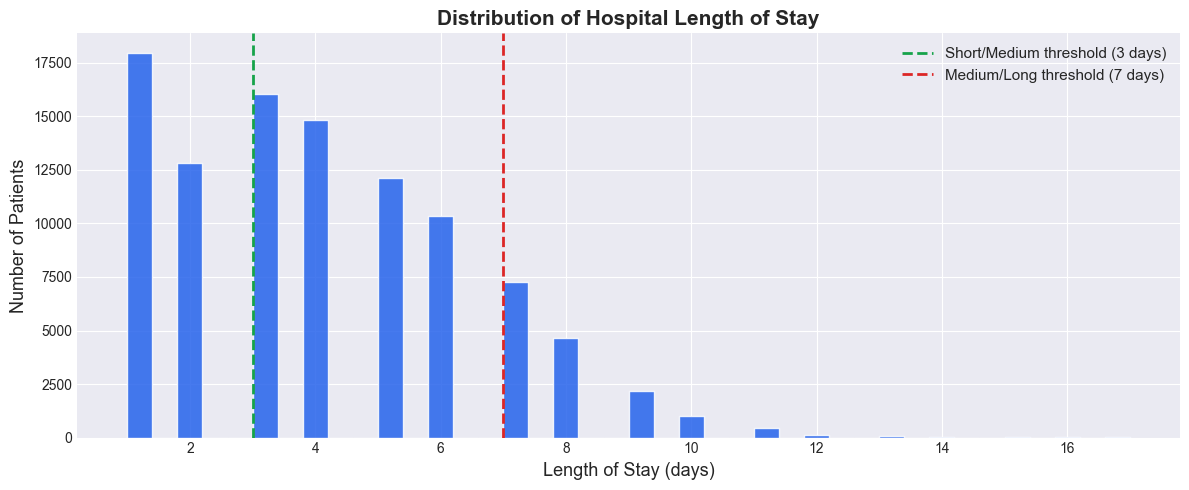

💡 So What? Most patients have short stays (0-3 days). Long-stay patients are fewer
   but consume disproportionate bed-days — making them the key prediction target.


In [6]:
# ── Plot 1: LOS Distribution
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df['lengthofstay'], bins=40, color='#2563EB', edgecolor='white', alpha=0.85)
ax.axvline(3, color='#16A34A', linestyle='--', lw=2, label='Short/Medium threshold (3 days)')
ax.axvline(7, color='#DC2626', linestyle='--', lw=2, label='Medium/Long threshold (7 days)')
ax.set_xlabel('Length of Stay (days)', fontsize=13)
ax.set_ylabel('Number of Patients', fontsize=13)
ax.set_title('Distribution of Hospital Length of Stay', fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('plot_01_los_distribution.png', dpi=150)
plt.show()
print('💡 So What? Most patients have short stays (0-3 days). Long-stay patients are fewer')
print('   but consume disproportionate bed-days — making them the key prediction target.')

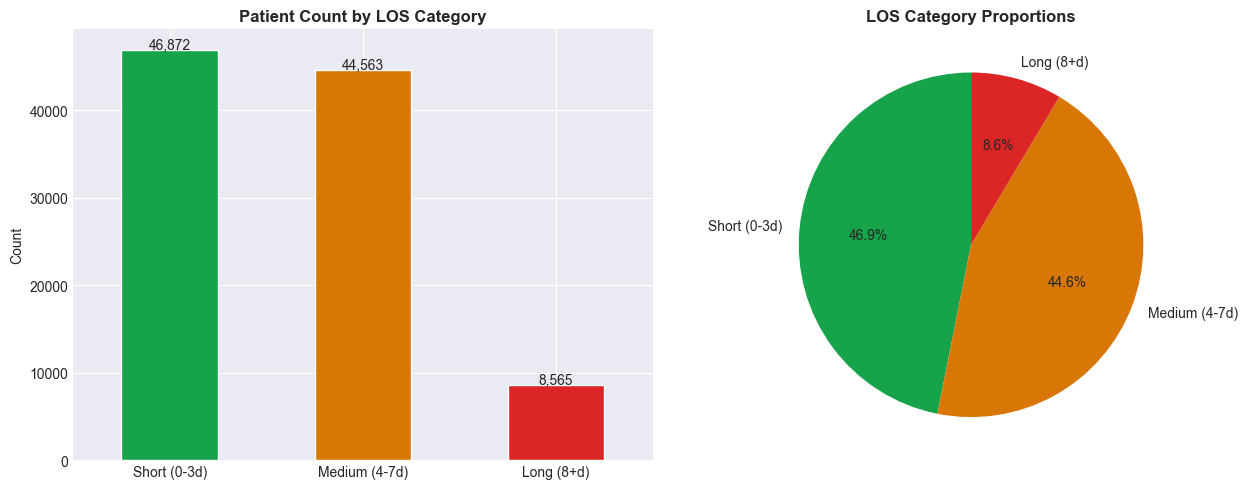

In [7]:
# ── LOS Category breakdown
def categorize_los(days):
    if days <= 3:   return 'Short (0-3d)'
    elif days <= 7: return 'Medium (4-7d)'
    else:           return 'Long (8+d)'

df['los_category'] = df['lengthofstay'].apply(categorize_los)
cat_counts = df['los_category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cat_counts.plot(kind='bar', ax=axes[0],
                color=['#16A34A', '#D97706', '#DC2626'], edgecolor='white')
axes[0].set_title('Patient Count by LOS Category', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(cat_counts):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=10)

axes[1].pie(cat_counts, labels=cat_counts.index,
            colors=['#16A34A', '#D97706', '#DC2626'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('LOS Category Proportions', fontweight='bold')

plt.tight_layout()
plt.savefig('plot_02_category_breakdown.png', dpi=150)
plt.show()

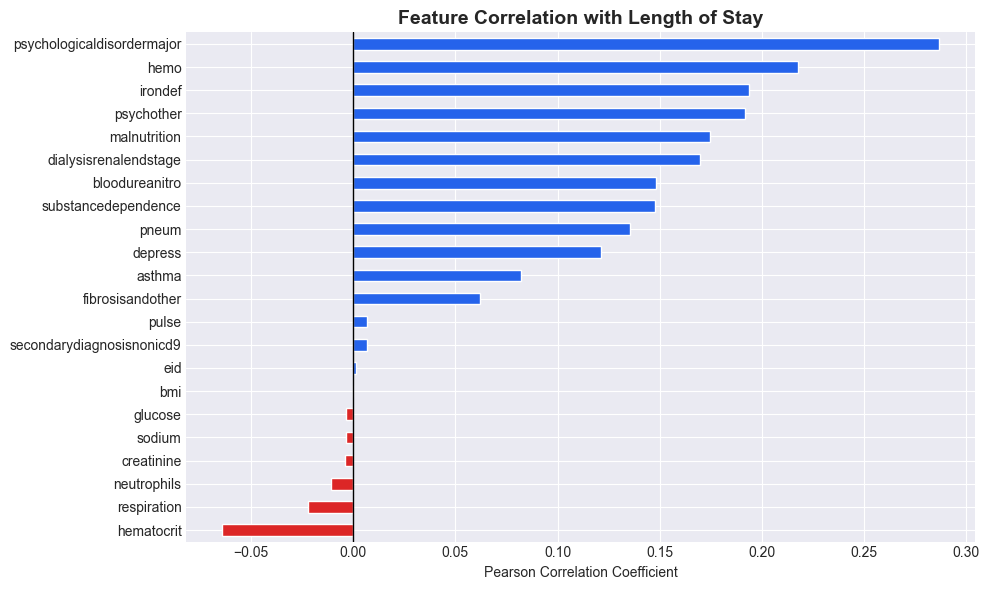

💡 So What? Features with high positive correlation increase LOS.
   These are the most clinically relevant admission-day risk factors.


In [8]:
# ── Numeric correlations with LOS
numeric_df = df.select_dtypes(include=np.number)
corr_with_los = numeric_df.corr()['lengthofstay'].drop('lengthofstay').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#DC2626' if v < 0 else '#2563EB' for v in corr_with_los]
corr_with_los.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=1)
ax.set_title('Feature Correlation with Length of Stay', fontweight='bold', fontsize=14)
ax.set_xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('plot_03_correlations.png', dpi=150)
plt.show()
print('💡 So What? Features with high positive correlation increase LOS.')
print('   These are the most clinically relevant admission-day risk factors.')

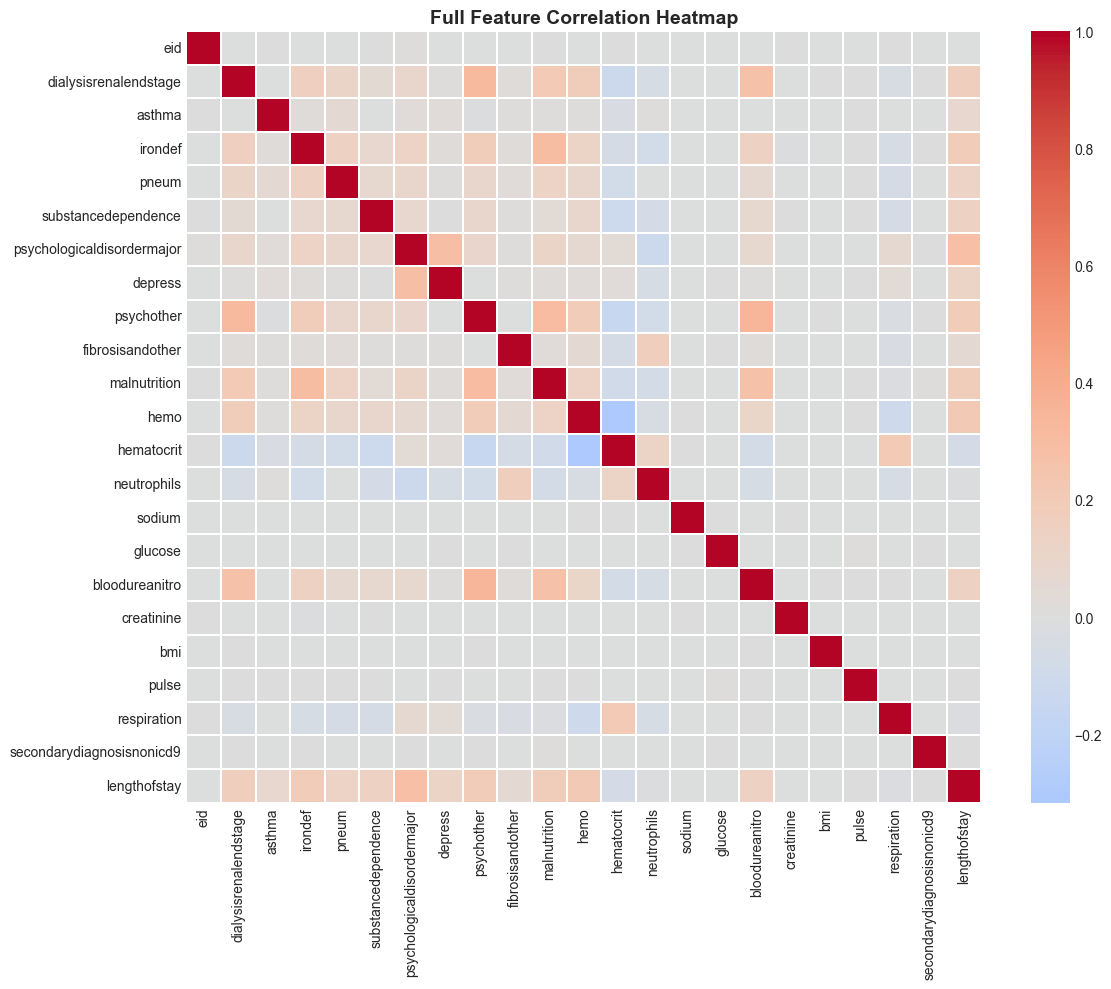

In [9]:
# ── Correlation heatmap (all numeric features)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm',
            center=0, ax=ax, linewidths=0.3)
ax.set_title('Full Feature Correlation Heatmap', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('plot_04_heatmap.png', dpi=150)
plt.show()

---
## 🧹 Step 3 — Data Preprocessing

In [10]:
df_model = df.drop(columns=['los_category']).copy()

# ── Drop leakage / ID columns
# 'discharged' leaks the answer (it contains discharge date)
drop_cols = ['eid', 'vdate', 'discharged', 'facid']
df_model.drop(columns=[c for c in drop_cols if c in df_model.columns], inplace=True)
print(f'Dropped leakage columns: {[c for c in drop_cols if c in df.columns]}')

# ── Convert Yes/No flags → 1/0
yn_cols = [c for c in df_model.columns
           if df_model[c].dtype == object
           and set(df_model[c].dropna().unique()).issubset({'Yes', 'No'})]
for col in yn_cols:
    df_model[col] = df_model[col].map({'Yes': 1, 'No': 0})
print(f'Binary encoded: {yn_cols}')

# ── Label encode remaining categoricals
le = LabelEncoder()
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))
print(f'Label encoded: {cat_cols}')

# ── Handle missing values
df_model.fillna(df_model.median(numeric_only=True), inplace=True)
print(f'Missing values remaining: {df_model.isnull().sum().sum()}')

print('\n✅ Preprocessing done!')
print(f'Final dataset shape: {df_model.shape}')

Dropped leakage columns: ['eid', 'vdate', 'discharged', 'facid']
Binary encoded: []
Label encoded: ['rcount', 'gender']
Missing values remaining: 0

✅ Preprocessing done!
Final dataset shape: (100000, 24)


In [11]:
# ── Define targets and features
y_reg = df_model['lengthofstay']            # Regression: continuous days
y_clf = df['los_category'].map({
    'Short (0-3d)':  0,
    'Medium (4-7d)': 1,
    'Long (8+d)':    2
})                                           # Classification: 0/1/2

X = df_model.drop(columns=['lengthofstay'])
feature_names = X.columns.tolist()

# ── Scale features (essential for KNN, SVM, Neural Network)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_names)

# ── Train/Test split (80/20)
X_train, X_test, yr_train, yr_test = train_test_split(X_scaled, y_reg, test_size=0.2, random_state=42)
_, _, yc_train, yc_test            = train_test_split(X_scaled, y_clf, test_size=0.2, random_state=42)

print(f'Train size: {X_train.shape[0]:,}  |  Test size: {X_test.shape[0]:,}')
print(f'Features: {len(feature_names)}')

Train size: 80,000  |  Test size: 20,000
Features: 23


---
## 📉 Step 4 — Regression Models (MUST: 2 + BONUS: 2)

In [12]:
# ── MUST Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, yr_train)
lr_preds = lr.predict(X_test)

lr_r2   = r2_score(yr_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(yr_test, lr_preds))
lr_mae  = mean_absolute_error(yr_test, lr_preds)

print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('MUST ① Linear Regression')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  R²   = {lr_r2:.4f}')
print(f'  RMSE = {lr_rmse:.4f} days')
print(f'  MAE  = {lr_mae:.4f} days')
print(f'\n💡 So What? The model explains {lr_r2*100:.1f}% of variance in LOS.')
print(f'   Average prediction error is {lr_rmse:.2f} days — useful for')
print(f'   department-level bed planning but not precise enough for individual patients.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MUST ① Linear Regression
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  R²   = 0.7522
  RMSE = 1.1661 days
  MAE  = 0.8911 days

💡 So What? The model explains 75.2% of variance in LOS.
   Average prediction error is 1.17 days — useful for
   department-level bed planning but not precise enough for individual patients.


In [13]:
# ── MUST Model 2: Decision Tree Regressor
dt = DecisionTreeRegressor(max_depth=6, random_state=42)
dt.fit(X_train, yr_train)
dt_preds = dt.predict(X_test)

dt_r2   = r2_score(yr_test, dt_preds)
dt_rmse = np.sqrt(mean_squared_error(yr_test, dt_preds))
dt_mae  = mean_absolute_error(yr_test, dt_preds)

print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('MUST ② Decision Tree Regressor')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  R²   = {dt_r2:.4f}')
print(f'  RMSE = {dt_rmse:.4f} days')
print(f'  MAE  = {dt_mae:.4f} days')
print(f'\n💡 So What? Decision Tree captures non-linear interactions (e.g., ICU + age).')
print(f'   It is interpretable — a doctor can follow the decision path to understand')
print(f'   why the model predicted a long stay.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MUST ② Decision Tree Regressor
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  R²   = 0.7633
  RMSE = 1.1396 days
  MAE  = 0.8856 days

💡 So What? Decision Tree captures non-linear interactions (e.g., ICU + age).
   It is interpretable — a doctor can follow the decision path to understand
   why the model predicted a long stay.


In [14]:
# ── BONUS Model 3: Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, yr_train)
rf_preds = rf.predict(X_test)

rf_r2   = r2_score(yr_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(yr_test, rf_preds))
rf_mae  = mean_absolute_error(yr_test, rf_preds)

print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('BONUS ★ Random Forest Regressor')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  R²   = {rf_r2:.4f}')
print(f'  RMSE = {rf_rmse:.4f} days')
print(f'  MAE  = {rf_mae:.4f} days')
print(f'\n💡 So What? Ensemble of 100 trees reduces overfitting vs a single Decision Tree.')
print(f'   RMSE improvement of {dt_rmse - rf_rmse:.2f} days over Decision Tree means')
print(f'   ~{int((dt_rmse - rf_rmse) * 1000)} fewer wasted bed-hours per 1000 patients.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BONUS ★ Random Forest Regressor
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  R²   = 0.9277
  RMSE = 0.6300 days
  MAE  = 0.3799 days

💡 So What? Ensemble of 100 trees reduces overfitting vs a single Decision Tree.
   RMSE improvement of 0.51 days over Decision Tree means
   ~509 fewer wasted bed-hours per 1000 patients.


In [15]:
# ── BONUS Model 4: XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb_model.fit(X_train, yr_train)
xgb_preds = xgb_model.predict(X_test)

xgb_r2   = r2_score(yr_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(yr_test, xgb_preds))
xgb_mae  = mean_absolute_error(yr_test, xgb_preds)

print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('BONUS ★ XGBoost Regressor')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  R²   = {xgb_r2:.4f}')
print(f'  RMSE = {xgb_rmse:.4f} days')
print(f'  MAE  = {xgb_mae:.4f} days')
print(f'\n💡 So What? XGBoost is the state-of-the-art benchmark for tabular clinical data.')
print(f'   Its gradient boosting framework handles missing values and outliers natively.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BONUS ★ XGBoost Regressor
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  R²   = 0.9624
  RMSE = 0.4544 days
  MAE  = 0.3385 days

💡 So What? XGBoost is the state-of-the-art benchmark for tabular clinical data.
   Its gradient boosting framework handles missing values and outliers natively.


In [16]:
# ── Regression Summary Table
reg_summary = pd.DataFrame({
    'Model':  ['Linear Regression (MUST)', 'Decision Tree (MUST)',
               'Random Forest ★ BONUS',    'XGBoost ★ BONUS'],
    'R²':     [lr_r2, dt_r2, rf_r2, xgb_r2],
    'RMSE':   [lr_rmse, dt_rmse, rf_rmse, xgb_rmse],
    'MAE':    [lr_mae, dt_mae, rf_mae, xgb_mae]
}).round(4)

print('\n📊 REGRESSION SUMMARY')
print(reg_summary.to_string(index=False))


📊 REGRESSION SUMMARY
                   Model     R²   RMSE    MAE
Linear Regression (MUST) 0.7522 1.1661 0.8911
    Decision Tree (MUST) 0.7633 1.1396 0.8856
   Random Forest ★ BONUS 0.9277 0.6300 0.3799
         XGBoost ★ BONUS 0.9624 0.4544 0.3385


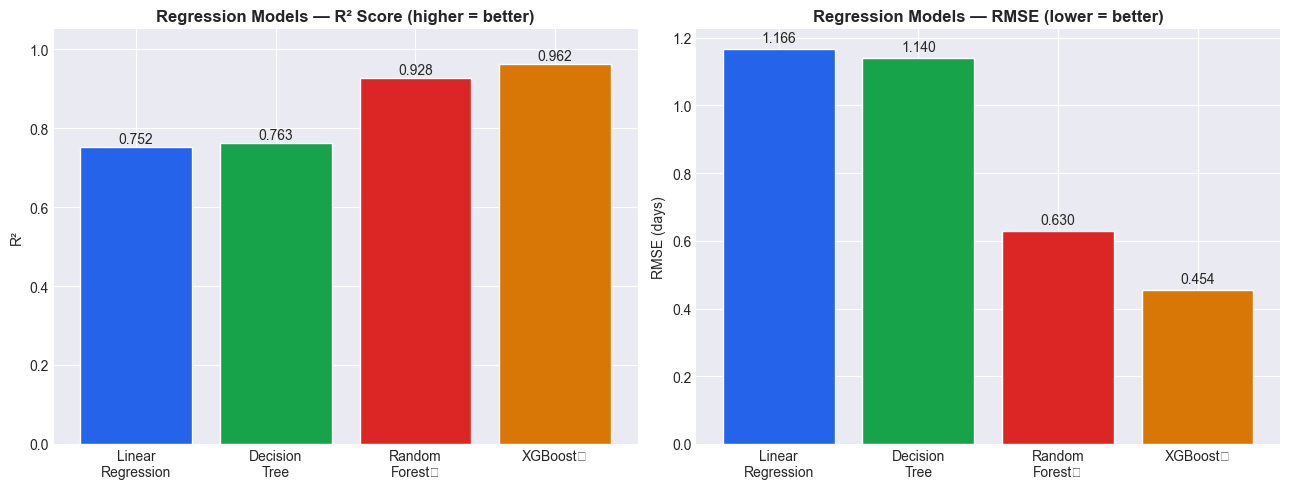

In [17]:
# ── Plot: Regression comparison
reg_names = ['Linear\nRegression', 'Decision\nTree', 'Random\nForest★', 'XGBoost★']
r2s   = [lr_r2,   dt_r2,   rf_r2,   xgb_r2]
rmses = [lr_rmse, dt_rmse, rf_rmse, xgb_rmse]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bars = axes[0].bar(reg_names, r2s, color=COLORS, edgecolor='white')
axes[0].set_title('Regression Models — R² Score (higher = better)', fontweight='bold')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1.05)
for bar, val in zip(bars, r2s):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center')

bars2 = axes[1].bar(reg_names, rmses, color=COLORS, edgecolor='white')
axes[1].set_title('Regression Models — RMSE (lower = better)', fontweight='bold')
axes[1].set_ylabel('RMSE (days)')
for bar, val in zip(bars2, rmses):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}', ha='center')

plt.tight_layout()
plt.savefig('plot_05_regression_comparison.png', dpi=150)
plt.show()

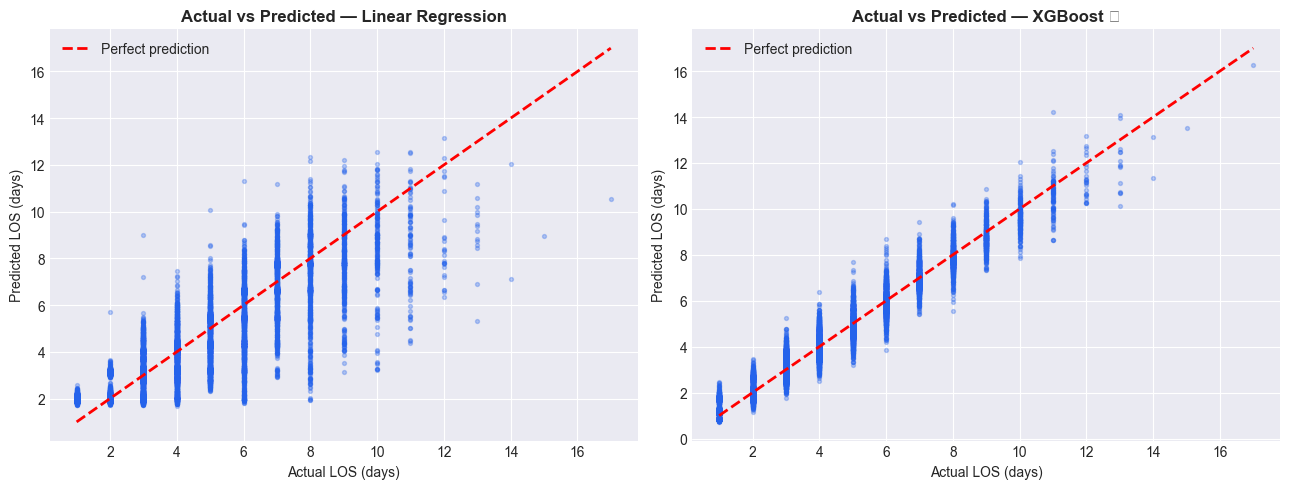

In [18]:
# ── Plot: Actual vs Predicted (best model)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, preds, name in [(axes[0], lr_preds, 'Linear Regression'),
                         (axes[1], xgb_preds, 'XGBoost ★')]:
    ax.scatter(yr_test, preds, alpha=0.3, s=8, color='#2563EB')
    ax.plot([yr_test.min(), yr_test.max()],
            [yr_test.min(), yr_test.max()], 'r--', lw=2, label='Perfect prediction')
    ax.set_xlabel('Actual LOS (days)')
    ax.set_ylabel('Predicted LOS (days)')
    ax.set_title(f'Actual vs Predicted — {name}', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig('plot_06_actual_vs_predicted.png', dpi=150)
plt.show()

---
## 📊 Step 5 — Classification Models (MUST: 2 + BONUS: 2)

In [19]:
CLASS_LABELS = ['Short (0-3d)', 'Medium (4-7d)', 'Long (8+d)']

def eval_classifier(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc  = accuracy_score(y_te, preds)
    prec = precision_score(y_te, preds, average='weighted', zero_division=0)
    rec  = recall_score(y_te, preds, average='weighted', zero_division=0)
    f1   = f1_score(y_te, preds, average='weighted', zero_division=0)
    cm   = confusion_matrix(y_te, preds)
    print(f'━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n{name}')
    print(f'  Accuracy  = {acc:.4f}')
    print(f'  Precision = {prec:.4f}')
    print(f'  Recall    = {rec:.4f}')
    print(f'  F1-Score  = {f1:.4f}')
    print(classification_report(y_te, preds, target_names=CLASS_LABELS, zero_division=0))
    return model, preds, cm, {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}

In [20]:
# ── MUST ①: Logistic Regression
log_model, log_preds, log_cm, log_scores = eval_classifier(
    'MUST ① Logistic Regression',
    LogisticRegression(max_iter=1000, random_state=42),
    X_train, yc_train, X_test, yc_test
)
print('💡 So What? Logistic Regression gives probability per class.')
print('   A patient with 85% probability of Long stay triggers early social work referral.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MUST ① Logistic Regression
  Accuracy  = 0.8105
  Precision = 0.8084
  Recall    = 0.8105
  F1-Score  = 0.8046
               precision    recall  f1-score   support

 Short (0-3d)       0.82      0.92      0.86      9340
Medium (4-7d)       0.81      0.77      0.79      8981
   Long (8+d)       0.76      0.45      0.57      1679

     accuracy                           0.81     20000
    macro avg       0.80      0.71      0.74     20000
 weighted avg       0.81      0.81      0.80     20000

💡 So What? Logistic Regression gives probability per class.
   A patient with 85% probability of Long stay triggers early social work referral.


In [21]:
# ── MUST ②: K-Nearest Neighbors
knn_model, knn_preds, knn_cm, knn_scores = eval_classifier(
    'MUST ② K-Nearest Neighbors (k=5)',
    KNeighborsClassifier(n_neighbors=5),
    X_train, yc_train, X_test, yc_test
)
print('💡 So What? KNN finds the 5 most similar past patients and uses their LOS.')
print('   Sensitive to feature scaling — which is why we applied StandardScaler.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MUST ② K-Nearest Neighbors (k=5)
  Accuracy  = 0.8036
  Precision = 0.8043
  Recall    = 0.8036
  F1-Score  = 0.7893
               precision    recall  f1-score   support

 Short (0-3d)       0.81      0.94      0.87      9340
Medium (4-7d)       0.80      0.76      0.78      8981
   Long (8+d)       0.82      0.26      0.40      1679

     accuracy                           0.80     20000
    macro avg       0.81      0.66      0.68     20000
 weighted avg       0.80      0.80      0.79     20000

💡 So What? KNN finds the 5 most similar past patients and uses their LOS.
   Sensitive to feature scaling — which is why we applied StandardScaler.


In [22]:
# ── BONUS ★: SVM
svm_model, svm_preds, svm_cm, svm_scores = eval_classifier(
    'BONUS ★ SVM (RBF Kernel)',
    SVC(kernel='rbf', probability=True, random_state=42),
    X_train, yc_train, X_test, yc_test
)
print('💡 So What? RBF kernel maps features to a higher-dimensional space,')
print('   finding non-linear boundaries between Short/Medium/Long stay classes.')

KeyboardInterrupt: 

In [23]:
# ── BONUS ★: Neural Network (MLP)
nn_model, nn_preds, nn_cm, nn_scores = eval_classifier(
    'BONUS ★ Neural Network (MLP)',
    MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300,
                  early_stopping=True, random_state=42),
    X_train, yc_train, X_test, yc_test
)
print('💡 So What? The MLP learns hierarchical feature combinations automatically.')
print('   Its performance vs SVM helps justify whether deep learning complexity is worth it')
print('   in a clinical setting where model interpretability also matters.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BONUS ★ Neural Network (MLP)
  Accuracy  = 0.8924
  Precision = 0.8916
  Recall    = 0.8924
  F1-Score  = 0.8919
               precision    recall  f1-score   support

 Short (0-3d)       0.92      0.94      0.93      9340
Medium (4-7d)       0.89      0.87      0.88      8981
   Long (8+d)       0.78      0.74      0.76      1679

     accuracy                           0.89     20000
    macro avg       0.86      0.85      0.86     20000
 weighted avg       0.89      0.89      0.89     20000

💡 So What? The MLP learns hierarchical feature combinations automatically.
   Its performance vs SVM helps justify whether deep learning complexity is worth it
   in a clinical setting where model interpretability also matters.


In [25]:
# ── Classification summary table
clf_summary = pd.DataFrame({
    'Model': ['Logistic Regression (MUST)', 'KNN (MUST)', 'Neural Net ★ BONUS'],
    'Accuracy':  [log_scores['Accuracy'],  knn_scores['Accuracy'],  nn_scores['Accuracy']],
    'Precision': [log_scores['Precision'], knn_scores['Precision'], nn_scores['Precision']],
    'Recall':    [log_scores['Recall'],    knn_scores['Recall'],    nn_scores['Recall']],
    'F1':        [log_scores['F1'],        knn_scores['F1'],        nn_scores['F1']],
}).round(4)

print('\n📊 CLASSIFICATION SUMMARY')
print(clf_summary.to_string(index=False))


📊 CLASSIFICATION SUMMARY
                     Model  Accuracy  Precision  Recall     F1
Logistic Regression (MUST)    0.8105     0.8084  0.8105 0.8046
                KNN (MUST)    0.8036     0.8043  0.8036 0.7893
        Neural Net ★ BONUS    0.8924     0.8916  0.8924 0.8919


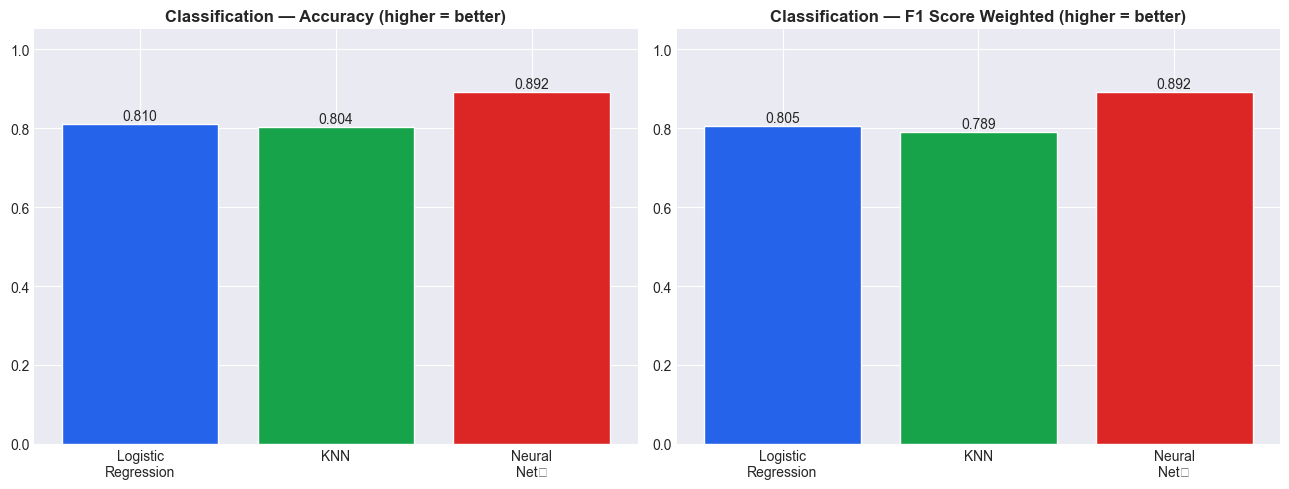

In [27]:
# ── Plot: Classification comparison
clf_names = ['Logistic\nRegression', 'KNN', 'Neural\nNet★']
accs = [log_scores['Accuracy'], knn_scores['Accuracy'], nn_scores['Accuracy']]
f1s  = [log_scores['F1'],       knn_scores['F1'],       nn_scores['F1']]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bars = axes[0].bar(clf_names, accs, color=COLORS, edgecolor='white')
axes[0].set_title('Classification — Accuracy (higher = better)', fontweight='bold')
axes[0].set_ylim(0, 1.05)
for bar, val in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center')

bars2 = axes[1].bar(clf_names, f1s, color=COLORS, edgecolor='white')
axes[1].set_title('Classification — F1 Score Weighted (higher = better)', fontweight='bold')
axes[1].set_ylim(0, 1.05)
for bar, val in zip(bars2, f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center')

plt.tight_layout()
plt.savefig('plot_07_classification_comparison.png', dpi=150)
plt.show()

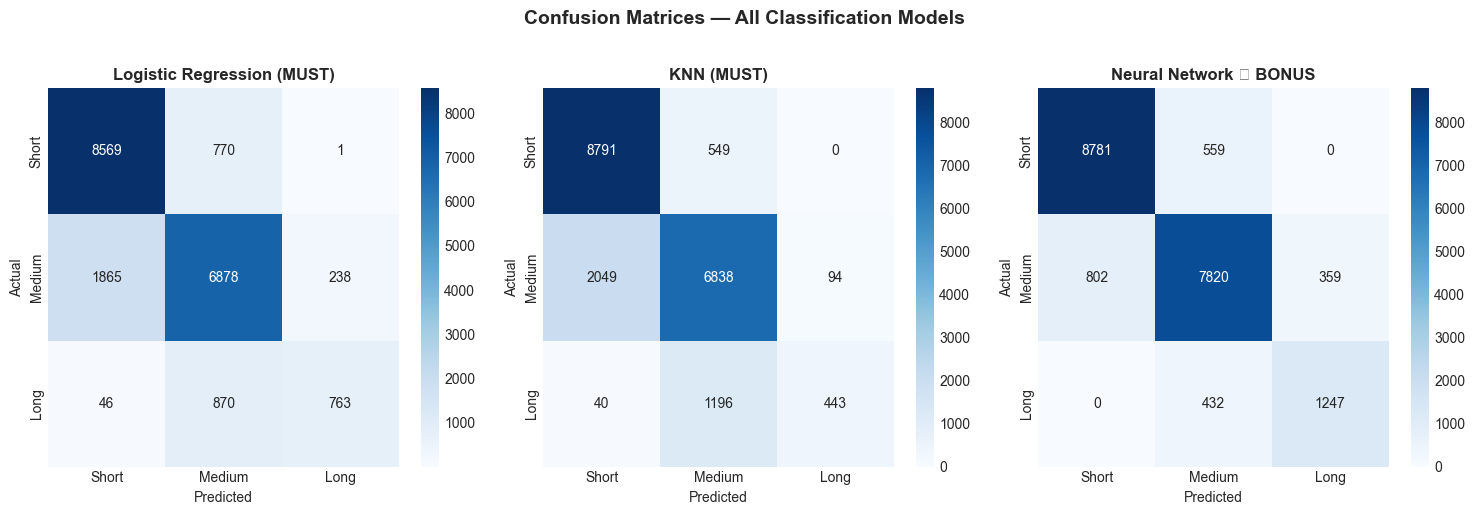

💡 So What? Off-diagonal cells show misclassifications.
   Short→Long errors waste beds. Long→Short errors cause premature discharge.


In [29]:
# ── Plot: Confusion matrices (all 3)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cms   = [log_cm,   knn_cm,   nn_cm]
names = ['Logistic Regression (MUST)', 'KNN (MUST)', 'Neural Network ★ BONUS']

for ax, cm, name in zip(axes.flatten(), cms, names):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Short', 'Medium', 'Long'],
                yticklabels=['Short', 'Medium', 'Long'])
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — All Classification Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_08_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 So What? Off-diagonal cells show misclassifications.')
print('   Short→Long errors waste beds. Long→Short errors cause premature discharge.')

---
## 🔥 Step 6 — Feature Importance (Random Forest)

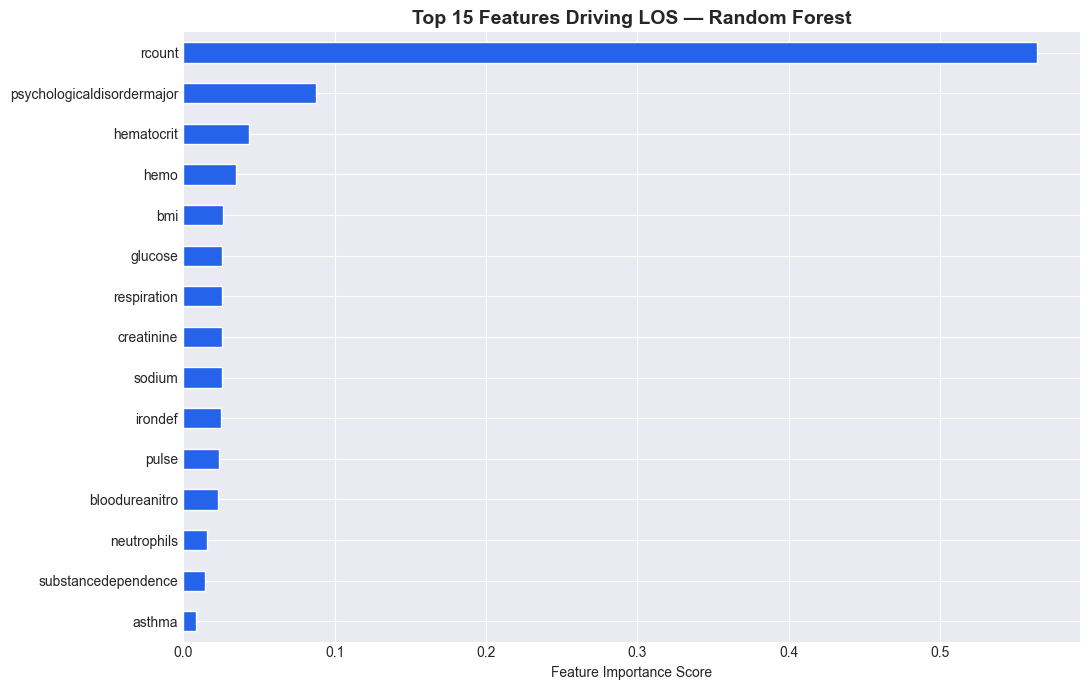

Top 5 most important features:
  rcount: 0.5643
  psychologicaldisordermajor: 0.0877
  hematocrit: 0.0435
  hemo: 0.0346
  bmi: 0.0261

💡 So What? These top features are the clinical factors that most determine LOS.
   Hospitals can create a rapid 5-question admission screen using these variables
   to flag high-risk patients on Day 1 for early discharge planning.


In [30]:
fi = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 7))
fi.head(15).sort_values().plot(kind='barh', ax=ax, color='#2563EB', edgecolor='white')
ax.set_title('Top 15 Features Driving LOS — Random Forest', fontweight='bold', fontsize=14)
ax.set_xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('plot_09_feature_importance.png', dpi=150)
plt.show()

print('Top 5 most important features:')
for feat, score in fi.head(5).items():
    print(f'  {feat}: {score:.4f}')

print('\n💡 So What? These top features are the clinical factors that most determine LOS.')
print('   Hospitals can create a rapid 5-question admission screen using these variables')
print('   to flag high-risk patients on Day 1 for early discharge planning.')

---
## 📋 Step 7 — Final Summary

In [31]:
print('=' * 60)
print('  FINAL PROJECT RESULTS SUMMARY')
print('=' * 60)
print('\n📉 REGRESSION MODELS')
print(reg_summary.to_string(index=False))
print('\n📊 CLASSIFICATION MODELS')
print(clf_summary.to_string(index=False))
print('\n✅ All plots saved:')
import glob
for f in sorted(glob.glob('plot_*.png')):
    print(f'   {f}')

  FINAL PROJECT RESULTS SUMMARY

📉 REGRESSION MODELS
                   Model     R²   RMSE    MAE
Linear Regression (MUST) 0.7522 1.1661 0.8911
    Decision Tree (MUST) 0.7633 1.1396 0.8856
   Random Forest ★ BONUS 0.9277 0.6300 0.3799
         XGBoost ★ BONUS 0.9624 0.4544 0.3385

📊 CLASSIFICATION MODELS
                     Model  Accuracy  Precision  Recall     F1
Logistic Regression (MUST)    0.8105     0.8084  0.8105 0.8046
                KNN (MUST)    0.8036     0.8043  0.8036 0.7893
        Neural Net ★ BONUS    0.8924     0.8916  0.8924 0.8919

✅ All plots saved:
   plot_01_los_distribution.png
   plot_02_category_breakdown.png
   plot_03_correlations.png
   plot_04_heatmap.png
   plot_05_regression_comparison.png
   plot_06_actual_vs_predicted.png
   plot_07_classification_comparison.png
   plot_08_confusion_matrices.png
   plot_09_feature_importance.png
